# Testing the `transPQtlColocH4Maximum` L2G Feature

This notebook walks through the trans-pQTL colocalisation feature logic step by step,
so you can inspect every intermediate DataFrame and validate the output.

**Feature logic diagram:**

```
GWAS locus ──[cis-pQTL coloc]──▶ localGene ──[STRING interaction]──▶ transGene ◀──[trans-pQTL coloc]── same GWAS locus
```

The feature fires for `localGene` when all three links exist, with value = max H4 from the trans-pQTL coloc side.


## 1. Session setup


In [1]:
import os
from pathlib import Path
import logging

import pyspark.sql.functions as f
from pyspark.sql import DataFrame

from gentropy.common.session import Session
from gentropy.dataset.colocalisation import Colocalisation
from gentropy.dataset.study_index import StudyIndex
from gentropy.dataset.study_locus import StudyLocus


def get_gcs_credentials() -> str:
    app_default_credentials = os.path.join(
        os.getenv("HOME", "."), ".config/gcloud/application_default_credentials.json"
    )
    if Path(app_default_credentials).exists():
        return app_default_credentials
    raise FileNotFoundError(
        "No GCS credentials found. Run: gcloud auth application-default login"
    )


def gcs_conf(project="open-targets-genetics-dev") -> dict[str, str]:
    credentials_path = get_gcs_credentials()
    return {
        "spark.driver.memory": "12g",
        "spark.kryoserializer.buffer.max": "500m",
        "spark.driver.maxResultSize": "2g",
        "spark.hadoop.fs.gs.impl": "com.google.cloud.hadoop.fs.gcs.GoogleHadoopFileSystem",
        "spark.jars": "https://storage.googleapis.com/hadoop-lib/gcs/gcs-connector-hadoop3-latest.jar",
        "spark.hadoop.google.cloud.auth.service.account.enable": "true",
        "spark.hadoop.fs.gs.project.id": project,
        "spark.hadoop.google.cloud.auth.service.account.json.keyfile": credentials_path,
        "spark.hadoop.fs.gs.requester.pays.mode": "AUTO",
    }


class GentropySession(Session):
    def __init__(self, *args, **kwargs):
        if "extended_spark_conf" in kwargs:
            kwargs["extended_spark_conf"].update(gcs_conf())
        else:
            kwargs["extended_spark_conf"] = gcs_conf()
        super().__init__(*args, **kwargs)


session = GentropySession()

Loading BokehJS ...

In [ ]:
x = session.spark.read.parquet(
    "gs://open-targets-pipeline-runs/yt/26.03-test-trasnpqts-1/intermediate/l2g_feature_matrix"
)

In [3]:
x.count()

26/04/30 16:49:39 INFO GhfsStorageStatistics: Detected potential high latency for operation stream_read_operations. latencyMs=516; previousMaxLatencyMs=456; operationCount=24; context=gs://open-targets-pipeline-runs/yt/26.03-test-trasnpqts-1/intermediate/l2g_feature_matrix/part-00047-da4e3541-5626-434c-ad6f-6cdeee2e4152-c000.snappy.parquet
26/04/30 16:49:39 INFO GhfsStorageStatistics: Detected potential high latency for operation stream_read_operations. latencyMs=545; previousMaxLatencyMs=516; operationCount=30; context=gs://open-targets-pipeline-runs/yt/26.03-test-trasnpqts-1/intermediate/l2g_feature_matrix/part-00042-da4e3541-5626-434c-ad6f-6cdeee2e4152-c000.snappy.parquet
26/04/30 16:49:39 INFO GhfsStorageStatistics: Detected potential high latency for operation stream_read_operations. latencyMs=617; previousMaxLatencyMs=545; operationCount=36; context=gs://open-targets-pipeline-runs/yt/26.03-test-trasnpqts-1/intermediate/l2g_feature_matrix/part-00038-da4e3541-5626-434c-ad6f-6cdeee2

58050449

In [4]:
x.printSchema()

root
 |-- geneId: string (nullable = true)
 |-- studyLocusId: string (nullable = true)
 |-- credibleSetConfidence: float (nullable = true)
 |-- distanceFootprintMean: float (nullable = true)
 |-- distanceFootprintMeanNeighbourhood: float (nullable = true)
 |-- distanceSentinelFootprint: float (nullable = true)
 |-- distanceSentinelFootprintNeighbourhood: float (nullable = true)
 |-- distanceSentinelTss: float (nullable = true)
 |-- distanceSentinelTssNeighbourhood: float (nullable = true)
 |-- distanceTssMean: float (nullable = true)
 |-- distanceTssMeanNeighbourhood: float (nullable = true)
 |-- e2gMean: float (nullable = true)
 |-- e2gMeanNeighbourhood: float (nullable = true)
 |-- eQtlColocClppMaximum: float (nullable = true)
 |-- eQtlColocClppMaximumNeighbourhood: float (nullable = true)
 |-- eQtlColocH4Maximum: float (nullable = true)
 |-- eQtlColocH4MaximumNeighbourhood: float (nullable = true)
 |-- geneCount500kb: double (nullable = true)
 |-- pQtlColocClppMaximum: float (nullab

In [ ]:
x.filter(f.col("transPQtlColocH4Maximum") > 0).count()

26/04/30 16:53:48 INFO GhfsStorageStatistics: Detected potential high latency for operation op_get_file_status. latencyMs=909; previousMaxLatencyMs=866; operationCount=1080; context=gs://open-targets-pipeline-runs/yt/26.03-test-trasnpqts-1/intermediate/l2g_feature_matrix/part-00058-da4e3541-5626-434c-ad6f-6cdeee2e4152-c000.snappy.parquet
26/04/30 16:54:22 INFO GhfsStorageStatistics: Detected potential high latency for operation stream_read_operations. latencyMs=2726; previousMaxLatencyMs=2713; operationCount=266755; context=gs://open-targets-pipeline-runs/yt/26.03-test-trasnpqts-1/intermediate/l2g_feature_matrix/part-00106-da4e3541-5626-434c-ad6f-6cdeee2e4152-c000.snappy.parquet
26/04/30 16:54:27 INFO GhfsStorageStatistics: Detected potential high latency for operation stream_read_operations. latencyMs=3054; previousMaxLatencyMs=2726; operationCount=273721; context=gs://open-targets-pipeline-runs/yt/26.03-test-trasnpqts-1/intermediate/l2g_feature_matrix/part-00119-da4e3541-5626-434c-ad

215639

In [ ]:
x.filter(
    (f.col("pQtlColocH4Maximum") > 0) & (f.col("transPQtlColocH4Maximum") > 0)
).count()

26/04/30 16:54:40 INFO GhfsStorageStatistics: Detected potential high latency for operation op_get_file_status. latencyMs=955; previousMaxLatencyMs=909; operationCount=1522; context=gs://open-targets-pipeline-runs/yt/26.03-test-trasnpqts-1/intermediate/l2g_feature_matrix/part-00137-da4e3541-5626-434c-ad6f-6cdeee2e4152-c000.snappy.parquet
26/04/30 16:54:53 INFO GhfsStorageStatistics: Detected potential high latency for operation op_open. latencyMs=1100; previousMaxLatencyMs=1048; operationCount=1605; context=gs://open-targets-pipeline-runs/yt/26.03-test-trasnpqts-1/intermediate/l2g_feature_matrix/part-00102-da4e3541-5626-434c-ad6f-6cdeee2e4152-c000.snappy.parquet
26/04/30 16:55:06 INFO GhfsStorageStatistics: Detected potential high latency for operation op_get_file_status. latencyMs=958; previousMaxLatencyMs=955; operationCount=1709; context=gs://open-targets-pipeline-runs/yt/26.03-test-trasnpqts-1/intermediate/l2g_feature_matrix/part-00039-da4e3541-5626-434c-ad6f-6cdeee2e4152-c000.snap

22544

In [ ]:
x.filter(f.col("pQtlColocH4Maximum") > 0).count()

165576

26/04/30 20:51:14 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56) ~[spark-common-utils_2.12-3.5.1.jar:3.5.1]
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310) ~[spark-core_2.12-3.5.1.jar:3.5.1]
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75) ~[spark-core_2.12-3.5.1.jar:3.5.1]
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102) ~[spark-core_2.12-3.5.1.jar:3.5.1]
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110) ~[spark-core_2.12-3.5.1.jar:3.5.1]
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36) ~[spark-core_2.12-3.5.1.jar:3.5.1]
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124) ~[spark-core_2.12-3.5.1.jar:3.5.1]
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage

## 2. Load datasets

Using the 26.03 release as reference.


In [ ]:
studdyLocus_to_keep = [
    "34acd1601af3dad242e951fcdd19cdb8",
    "3d527309b7adbbfdd39cd89dd8dd1d99",
    "53681a273c6be54bd2458f343e526d9c",
    "331ba7b4af882392e5100a83e0bd6149",
]

In [ ]:
RELEASE = "/Users/yt4/Projects/gentropy/inter_data/26.03/"

si = StudyIndex.from_parquet(session, RELEASE + "study/")
sl = StudyLocus.from_parquet(session, RELEASE + "credible_set/")
# sl=sl.filter(f.col("studyLocusId").isin(studdyLocus_to_keep))
coloc = Colocalisation.from_parquet(session, RELEASE + "colocalisation/")
interactions = session.spark.read.parquet(RELEASE + "interaction/")
target = session.spark.read.parquet(RELEASE + "target/")

print(f"StudyIndex:      {si.df.count():,}")
print(f"StudyLocus:      {sl.df.count():,}")
print(f"Colocalisation:  {coloc.df.count():,}")
print(f"Interactions:    {interactions.count():,}")
print(f"target:    {target.count():,}")

26/05/07 11:36:01 INFO ContextHandler: Started o.s.j.s.ServletContextHandler@5b72aa0{/SQL,null,AVAILABLE,@Spark}
26/05/07 11:36:01 INFO ContextHandler: Started o.s.j.s.ServletContextHandler@7cb7a44b{/SQL/json,null,AVAILABLE,@Spark}
26/05/07 11:36:01 INFO ContextHandler: Started o.s.j.s.ServletContextHandler@43950271{/SQL/execution,null,AVAILABLE,@Spark}
26/05/07 11:36:01 INFO ContextHandler: Started o.s.j.s.ServletContextHandler@7e2ff232{/SQL/execution/json,null,AVAILABLE,@Spark}
26/05/07 11:36:01 INFO ContextHandler: Started o.s.j.s.ServletContextHandler@2f21e626{/static/sql,null,AVAILABLE,@Spark}


StudyIndex:      2,001,827
StudyLocus:      3,491,182


Colocalisation:  217,914,314
Interactions:    14,618,053
target:    78,691


## 3. Inspect the interaction dataset

The feature expects the **aggregated** interaction dataset (not interaction_evidence).
It should have flat columns: `sourceDatabase`, `targetA`, `targetB`, `scoring`.


In [4]:
interactions.printSchema()

root
 |-- sourceDatabase: string (nullable = true)
 |-- targetA: string (nullable = true)
 |-- intA: string (nullable = true)
 |-- intABiologicalRole: string (nullable = true)
 |-- targetB: string (nullable = true)
 |-- intB: string (nullable = true)
 |-- intBBiologicalRole: string (nullable = true)
 |-- speciesA: struct (nullable = true)
 |    |-- mnemonic: string (nullable = true)
 |    |-- scientificName: string (nullable = true)
 |    |-- taxonId: long (nullable = true)
 |-- speciesB: struct (nullable = true)
 |    |-- mnemonic: string (nullable = true)
 |    |-- scientificName: string (nullable = true)
 |    |-- taxonId: long (nullable = true)
 |-- count: long (nullable = true)
 |-- scoring: double (nullable = true)



In [ ]:
interactions.filter(f.col("sourceDatabase") == "string").show(2)

+--------------+---------------+---------------+------------------+---------------+---------------+------------------+--------------------+--------------------+-----+-------+
|sourceDatabase|        targetA|           intA|intABiologicalRole|        targetB|           intB|intBBiologicalRole|            speciesA|            speciesB|count|scoring|
+--------------+---------------+---------------+------------------+---------------+---------------+------------------+--------------------+--------------------+-----+-------+
|        string|ENSG00000004059|ENSP00000000233|  unspecified role|ENSG00000162222|ENSP00000325266|  unspecified role|{human, Homo sapi...|{human, Homo sapi...|    2|   0.18|
|        string|ENSG00000004059|ENSP00000000233|  unspecified role|ENSG00000274523|ENSP00000480364|  unspecified role|{human, Homo sapi...|{human, Homo sapi...|    2|  0.154|
+--------------+---------------+---------------+------------------+---------------+---------------+------------------+-------

In [5]:
interactions.groupBy("sourceDatabase").agg(
    f.count("*").alias("count"),
    f.min("scoring").alias("min_score"),
    f.max("scoring").alias("max_score"),
).show()

+--------------+--------+---------+---------+
|sourceDatabase|   count|min_score|max_score|
+--------------+--------+---------+---------+
|        intact| 1311132|     0.22|      1.0|
|        signor|   39992|     NULL|     NULL|
|      reactome|   56191|     NULL|     NULL|
|        string|13210738|     0.15|    0.999|
+--------------+--------+---------+---------+



In [ ]:
string_threshold = 1.01
intact_threshold = 0.42

filtered_inter = (
    interactions.filter(
        ((f.col("sourceDatabase") == "string") & (f.col("scoring") >= string_threshold))
        | (
            (f.col("sourceDatabase") == "intact")
            & (f.col("scoring") >= intact_threshold)
        )
        | (
            ~f.col("sourceDatabase").isin("string", "intact")
        )  # keep all other datasources unchanged
    )
    .select("targetA", "targetB")
    .distinct()
)
print(f"Filtered interaction pairs: {filtered_inter.count():,}")
filtered_inter.show(5, truncate=False)

Filtered interaction pairs: 422,219
+---------------+---------------+
|targetA        |targetB        |
+---------------+---------------+
|ENSG00000170027|ENSG00000160741|
|ENSG00000186298|ENSG00000104881|
|ENSG00000169083|ENSG00000000938|
|ENSG00000055130|ENSG00000116663|
|ENSG00000111276|ENSG00000134308|
+---------------+---------------+
only showing top 5 rows



In [ ]:
extended_inter = (
    filtered_inter.select("targetA", "targetB")
    .unionByName(
        filtered_inter.select(
            f.col("targetB").alias("targetA"),
            f.col("targetA").alias("targetB"),
        )
    )
    .filter(f.col("targetA") != f.col("targetB"))
    .filter(f.col("targetA").isNotNull())
    .filter(f.col("targetB").isNotNull())
    .distinct()
).cache()
extended_inter.count()

415728

In [12]:
extended_inter.show(1)

+---------------+---------------+
|        targetA|        targetB|
+---------------+---------------+
|ENSG00000170027|ENSG00000160741|
+---------------+---------------+
only showing top 1 row



In [13]:
target.show(1)

+---------------+--------------+--------------+--------------------+--------------------+--------------------+--------------------+--------------------+----------------+-------------+--------------------+---------+--------------------+--------------------+--------------------+--------------------+--------------------+-----------+----------------+--------------------+----------+----+--------------------+--------------------+--------------+--------------------+--------------------+-----------------+--------+---------+
|             id|approvedSymbol|       biotype|       transcriptIds|         transcripts| canonicalTranscript|      canonicalExons|     genomicLocation|alternativeGenes| approvedName|                  go|hallmarks|            synonyms|      symbolSynonyms|        nameSynonyms|functionDescriptions|subcellularLocations|targetClass| obsoleteSymbols|       obsoleteNames|constraint| tep|          proteinIds|             dbXrefs|chemicalProbes|          homologues|        tractab

In [14]:
target.printSchema()

root
 |-- id: string (nullable = true)
 |-- approvedSymbol: string (nullable = true)
 |-- biotype: string (nullable = true)
 |-- transcriptIds: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- transcripts: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- transcriptId: string (nullable = true)
 |    |    |-- biotype: string (nullable = true)
 |    |    |-- uniprotId: string (nullable = true)
 |    |    |-- isUniprotReviewed: boolean (nullable = true)
 |    |    |-- translationId: string (nullable = true)
 |    |    |-- alphafoldId: string (nullable = true)
 |    |    |-- uniprotIsoformId: string (nullable = true)
 |    |    |-- isEnsemblCanonical: boolean (nullable = true)
 |-- canonicalTranscript: struct (nullable = true)
 |    |-- id: string (nullable = true)
 |    |-- chromosome: string (nullable = true)
 |    |-- start: long (nullable = true)
 |    |-- end: long (nullable = true)
 |    |-- strand: string (nullable = t

In [ ]:
extended_inter = (
    extended_inter.join(
        target.select("id", "tss", "genomicLocation.chromosome")
        .withColumnRenamed("id", "targetB")
        .withColumnRenamed("chromosome", "targetB_chromosome")
        .withColumnRenamed("tss", "targetB_tss"),
        on="targetB",
        how="inner",
    )
).cache()
extended_inter.count()

415049

In [16]:
extended_inter.show(1)

+---------------+---------------+-----------+------------------+
|        targetB|        targetA|targetB_tss|targetB_chromosome|
+---------------+---------------+-----------+------------------+
|ENSG00000160741|ENSG00000170027|  153958612|                 1|
+---------------+---------------+-----------+------------------+
only showing top 1 row



# 4. The Logic of the feature


In [ ]:
trans_pqtl_study_loci = sl.df.filter(
    (f.col("isTransQtl").isNotNull()) & f.col("isTransQtl")
).select("studyLocusId", "studyId")
print(f"Trans-pQTL study loci: {trans_pqtl_study_loci.count():,}")
trans_pqtl_study_loci.show(5, truncate=False)

Trans-pQTL study loci: 17,665
+--------------------------------+--------------------------------------+
|studyLocusId                    |studyId                               |
+--------------------------------+--------------------------------------+
|c76845b354ef497d64b42d0548d022db|UKB_PPP_EUR_INPP5J_Q15735_OID30975_v1 |
|3f3fe1b00cfee5247a9e9e85b8ab1f0b|UKB_PPP_EUR_CEACAM8_P31997_OID20102_v1|
|798a909acb0cfb8694bc22eab0cdd148|UKB_PPP_EUR_CEACAM8_P31997_OID20102_v1|
|acb2bdd057ddada3f053d1883138b954|UKB_PPP_EUR_CEACAM8_P31997_OID20102_v1|
|d5c8474f695123b722adff75616a13fc|UKB_PPP_EUR_ENTPD2_Q9Y5L3_OID21260_v1 |
+--------------------------------+--------------------------------------+
only showing top 5 rows



In [ ]:
trans_pqtl_study_loci = trans_pqtl_study_loci.join(
    si.df.select("studyId", "geneId"), on="studyId", how="inner"
).cache()
trans_pqtl_study_loci.count()

17665

In [19]:
trans_pqtl_study_loci.show(10)

+--------------------+--------------------+---------------+
|             studyId|        studyLocusId|         geneId|
+--------------------+--------------------+---------------+
|UKB_PPP_EUR_INPP5...|c76845b354ef497d6...|ENSG00000185133|
|UKB_PPP_EUR_CEACA...|3f3fe1b00cfee5247...|ENSG00000124469|
|UKB_PPP_EUR_CEACA...|798a909acb0cfb869...|ENSG00000124469|
|UKB_PPP_EUR_CEACA...|acb2bdd057ddada3f...|ENSG00000124469|
|UKB_PPP_EUR_ENTPD...|d5c8474f695123b72...|ENSG00000054179|
|UKB_PPP_EUR_SEMA3...|5e243f603d46c101b...|ENSG00000010319|
|UKB_PPP_EUR_CEACA...|b86cac0104694d04f...|ENSG00000124469|
|UKB_PPP_EUR_SCGB1...|56db3b30fcd86a665...|ENSG00000149021|
|UKB_PPP_EUR_TFRC_...|7c04f2cbf9ef185fa...|ENSG00000072274|
|UKB_PPP_EUR_CLEC4...|b9d45c2bc7f17aed9...|ENSG00000198178|
+--------------------+--------------------+---------------+
only showing top 10 rows



### Merge with coloc


In [20]:
coloc.df.show(10)

+--------------------+--------------------+--------------+----------+--------------------+--------------------------+----+----+----+--------------------+------------------+--------------------+--------------------+
|    leftStudyLocusId|   rightStudyLocusId|rightStudyType|chromosome|colocalisationMethod|numberColocalisingVariants|  h0|  h1|  h2|                  h3|                h4|                clpp|betaRatioSignAverage|
+--------------------+--------------------+--------------+----------+--------------------+--------------------------+----+----+----+--------------------+------------------+--------------------+--------------------+
|000137480641fd8b2...|61820e587201b0297...|          eqtl|         1|   COLOC_PIP_ECAVIAR|                        68|NULL|NULL|NULL| 0.31174292114726465|0.6882570788527371| 0.00198976606726513|                NULL|
|00057b7c44db64b74...|f6931ab51d6457b15...|          eqtl|         2|   COLOC_PIP_ECAVIAR|                         4|NULL|NULL|NULL|  0.2520

In [ ]:
coloc_trans = coloc.df.join(
    trans_pqtl_study_loci.withColumnRenamed(
        "studyLocusId", "rightStudyLocusId"
    ).withColumnRenamed("geneId", "transPQTLGeneId"),
    on="rightStudyLocusId",
    how="inner",
)

In [ ]:
coloc_trans = (
    coloc_trans.drop("chromosome")
    .join(
        sl.df.select("studyLocusId", "chromosome", "position").withColumnRenamed(
            "studyLocusId", "leftStudyLocusId"
        ),
        on="leftStudyLocusId",
        how="inner",
    )
    .cache()
)
coloc_trans.count()

6072554

In [23]:
coloc_trans.show(10)

+--------------------+--------------------+--------------+--------------------+--------------------------+----+----+----+--------------------+------------------+--------------------+--------------------+--------------------+---------------+----------+---------+
|    leftStudyLocusId|   rightStudyLocusId|rightStudyType|colocalisationMethod|numberColocalisingVariants|  h0|  h1|  h2|                  h3|                h4|                clpp|betaRatioSignAverage|             studyId|transPQTLGeneId|chromosome| position|
+--------------------+--------------------+--------------+--------------------+--------------------------+----+----+----+--------------------+------------------+--------------------+--------------------+--------------------+---------------+----------+---------+
|0005218bc3a62e387...|1b26712ff90ed1cef...|          pqtl|   COLOC_PIP_ECAVIAR|                         1|NULL|NULL|NULL|                 0.0|               1.0|  0.9944776974760923|                -1.0|UKB_PPP_EUR

In [ ]:
# coloc_trans.filter(f.col("leftStudyLocusId").isin(studdyLocus_to_keep)).show(10, truncate=False)

In [25]:
extended_inter.show(1)

+---------------+---------------+-----------+------------------+
|        targetB|        targetA|targetB_tss|targetB_chromosome|
+---------------+---------------+-----------+------------------+
|ENSG00000160741|ENSG00000170027|  153958612|                 1|
+---------------+---------------+-----------+------------------+
only showing top 1 row



In [ ]:
delta = 500_000
coloc_trans_inter = (
    coloc_trans.join(
        extended_inter.withColumnRenamed("targetA", "transPQTLGeneId"),
        on="transPQTLGeneId",
        how="inner",
    )
    .filter(f.col("targetB_chromosome") == f.col("chromosome"))
    .filter(f.abs(f.col("targetB_tss") - f.col("position")) <= delta)
).cache()

In [27]:
coloc_trans_inter.count()

163251

In [28]:
coloc_trans_inter.show(1)

+---------------+--------------------+--------------------+--------------+--------------------+--------------------------+----+----+----+---+---+------------------+--------------------+--------------------+----------+--------+---------------+-----------+------------------+
|transPQTLGeneId|    leftStudyLocusId|   rightStudyLocusId|rightStudyType|colocalisationMethod|numberColocalisingVariants|  h0|  h1|  h2| h3| h4|              clpp|betaRatioSignAverage|             studyId|chromosome|position|        targetB|targetB_tss|targetB_chromosome|
+---------------+--------------------+--------------------+--------------+--------------------+--------------------------+----+----+----+---+---+------------------+--------------------+--------------------+----------+--------+---------------+-----------+------------------+
|ENSG00000090554|906cac32d7ed7341a...|e438cd9acb1fb3e85...|          pqtl|   COLOC_PIP_ECAVIAR|                         1|NULL|NULL|NULL|0.0|1.0|0.9902334836469219|              

In [ ]:
transpqtl_maxh4_feature = (
    coloc_trans_inter.filter(f.col("colocalisationMethod") == "COLOC_PIP_ECAVIAR")
    .select(
        f.col("leftStudyLocusId").alias("studyLocusId"),
        f.col("targetB").alias("geneId"),
        f.col("h4"),
    )
    .groupBy("studyLocusId", "geneId")
    .agg(f.max("h4").alias("transPQtlColocH4Maximum"))
    .cache()
)
transpqtl_maxh4_feature.count()

113486

In [30]:
transpqtl_maxh4_feature.show(4)

+--------------------+---------------+-----------------------+
|        studyLocusId|         geneId|transPQtlColocH4Maximum|
+--------------------+---------------+-----------------------+
|aee9695d1f498bc42...|ENSG00000122025|                    1.0|
|7155f15228c93ef48...|ENSG00000122025|                    1.0|
|f353f0eb2f25d2818...|ENSG00000122025|                    1.0|
|9f8ef5da7cb52a7c8...|ENSG00000122025|                    1.0|
+--------------------+---------------+-----------------------+
only showing top 4 rows



In [31]:
transpqtl_maxh4_feature.select("studyLocusId").distinct().count()

63880

In [ ]:
transpqtl_maxh4_feature.select("geneId").distinct().count()

346

26/05/07 15:38:08 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56) ~[spark-common-utils_2.12-3.5.1.jar:3.5.1]
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310) ~[spark-core_2.12-3.5.1.jar:3.5.1]
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75) ~[spark-core_2.12-3.5.1.jar:3.5.1]
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102) ~[spark-core_2.12-3.5.1.jar:3.5.1]
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110) ~[spark-core_2.12-3.5.1.jar:3.5.1]
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36) ~[spark-core_2.12-3.5.1.jar:3.5.1]
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124) ~[spark-core_2.12-3.5.1.jar:3.5.1]
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage

## 5. Run via the feature class

`TransPQtlColocH4MaximumFeature.compute()` now implements the same logic as Chapter 4.  
It requires `target_index` (a `TargetIndex` dataset) in addition to `colocalisation`, `study_index`, `study_locus`, and `interactions`.


In [29]:
from gentropy.dataset.l2g_features.colocalisation import TransPQtlColocH4MaximumFeature
from gentropy.dataset.target_index import TargetIndex

target_index = TargetIndex.from_parquet(session, RELEASE + "target/")

gwas_loci = sl.filter(f.col("studyType") == "gwas")

feature = TransPQtlColocH4MaximumFeature.compute(
    study_loci_to_annotate=gwas_loci,
    feature_dependency={
        "colocalisation": coloc,
        "study_index": si,
        "study_locus": sl,
        "interactions": interactions,
        "target_index": target_index,
    },
)

print(f"Feature rows from compute(): {feature.df.count():,}")
feature.df.show(10, truncate=False)

Feature rows from compute(): 215,639


+--------------------------------+---------------+-----------------------+------------+
|studyLocusId                    |geneId         |featureName            |featureValue|
+--------------------------------+---------------+-----------------------+------------+
|0000570b33d89bb53bc41e5eab881405|ENSG00000116299|transPQtlColocH4Maximum|0.9928614   |
|0000570b33d89bb53bc41e5eab881405|ENSG00000134243|transPQtlColocH4Maximum|0.9928614   |
|0000570b33d89bb53bc41e5eab881405|ENSG00000181754|transPQtlColocH4Maximum|0.9935965   |
|0004845fe9578b3dae80e23c0e107245|ENSG00000058085|transPQtlColocH4Maximum|0.78405815  |
|0004845fe9578b3dae80e23c0e107245|ENSG00000135862|transPQtlColocH4Maximum|0.78405815  |
|0012982ba0ba11faec1073f5f7748541|ENSG00000000971|transPQtlColocH4Maximum|0.9559656   |
|0012982ba0ba11faec1073f5f7748541|ENSG00000134365|transPQtlColocH4Maximum|0.9559656   |
|0014d6ba4db3bb02bea79c22d0d5c853|ENSG00000173578|transPQtlColocH4Maximum|0.84091884  |
|0014d6ba4db3bb02bea79c22d0d5c85

In [30]:
feature.df.printSchema()
feature.df.describe("featureValue").show()

root
 |-- studyLocusId: string (nullable = true)
 |-- geneId: string (nullable = true)
 |-- featureName: string (nullable = false)
 |-- featureValue: float (nullable = true)



+-------+-------------------+
|summary|       featureValue|
+-------+-------------------+
|  count|             215639|
|   mean| 0.9588020854486283|
| stddev|0.11064533984209063|
|    min|       1.6718762E-4|
|    max|                1.0|
+-------+-------------------+



## 6. Compare with Chapter 4 reference

Both paths should produce identical `(studyLocusId, geneId, featureValue)` triples.


In [ ]:
feature_wide = feature.df.select(
    "studyLocusId",
    "geneId",
    f.col("featureValue").cast("double").alias("h4_class"),
)

comparison = transpqtl_maxh4_feature.join(
    feature_wide, on=["studyLocusId", "geneId"], how="full"
)

matched = comparison.filter(
    f.col("transPQtlColocH4Maximum").isNotNull() & f.col("h4_class").isNotNull()
).count()
only_ch4 = comparison.filter(f.col("h4_class").isNull()).count()
only_cls = comparison.filter(f.col("transPQtlColocH4Maximum").isNull()).count()

print(f"Chapter 4 rows:        {transpqtl_maxh4_feature.count():,}")
print(f"Feature class rows:    {feature_wide.count():,}")
print(f"Matched pairs:         {matched:,}")
print(f"Only in Ch4:           {only_ch4:,}")
print(f"Only in feature class: {only_cls:,}")

# Max absolute difference in H4 on matched pairs
comparison.filter(
    f.col("transPQtlColocH4Maximum").isNotNull() & f.col("h4_class").isNotNull()
).agg(
    f.max(f.abs(f.col("transPQtlColocH4Maximum") - f.col("h4_class"))).alias(
        "max_abs_diff"
    )
).show()

Chapter 4 rows:        215,639


Feature class rows:    215,639
Matched pairs:         215,639
Only in Ch4:           0
Only in feature class: 0


+--------------------+
|        max_abs_diff|
+--------------------+
|2.980161839527539...|
+--------------------+



## 7. Run via the full feature matrix pipeline

Test alongside `pQtlColocH4Maximum` through the `L2GFeatureInputLoader`.


In [32]:
from gentropy.method.l2g.feature_factory import L2GFeatureInputLoader

features_list = [
    "pQtlColocH4Maximum",
    "transPQtlColocH4Maximum",
]

features_input_loader = L2GFeatureInputLoader(
    colocalisation=coloc,
    study_index=si,
    study_locus=sl,
    interactions=interactions,
    target_index=target_index,
)

fm = gwas_loci.build_feature_matrix(
    features_list,
    features_input_loader,
)

print(f"Feature matrix rows: {fm._df.count():,}")
fm._df.show(10, truncate=False)

Feature matrix rows: 358,671


+--------------------------------+---------------+------------------+-----------------------+
|studyLocusId                    |geneId         |pQtlColocH4Maximum|transPQtlColocH4Maximum|
+--------------------------------+---------------+------------------+-----------------------+
|25fc6c54a34e72a8c290ac53a02719ec|ENSG00000197272|0.99261963        |0.99261963             |
|755cfa553d8e93a7624a4f1c1391f2ed|ENSG00000110243|0.99986535        |0.99986535             |
|a94fd147726649dabc74e27500680392|ENSG00000174807|0.9923383         |0.0                    |
|018133a02901b5c2dd086cd90761ffc1|ENSG00000196502|0.46471807        |0.0                    |
|83b3e7dcf6246a53ea089060af543f04|ENSG00000108578|0.97943217        |0.0                    |
|e52cacc6af554554afb8c0f7151edd8b|ENSG00000112964|0.9780514         |0.0                    |
|0dfe54148224bdb69123ccfbc06cac84|ENSG00000223572|0.8401379         |0.0                    |
|4e076d94fd14ff15fc70d89d86132da8|ENSG00000100097|1.0       

In [ ]:
fm._df.select(
    f.count("*").alias("total_rows"),
    f.sum(f.when(f.col("transPQtlColocH4Maximum").isNotNull(), 1).otherwise(0)).alias(
        "has_trans_pqtl"
    ),
    f.sum(f.when(f.col("pQtlColocH4Maximum").isNotNull(), 1).otherwise(0)).alias(
        "has_cis_pqtl"
    ),
).show()

+----------+--------------+------------+
|total_rows|has_trans_pqtl|has_cis_pqtl|
+----------+--------------+------------+
|    358671|        358671|      358671|
+----------+--------------+------------+



## 8. Sanity checks


In [ ]:
# Check 1: feature name is always 'transPQtlColocH4Maximum'
feature.df.select("featureName").distinct().show()
assert feature.df.select("featureName").distinct().count() == 1, (
    "Unexpected feature names!"
)
print("✓ featureName correct")

+--------------------+
|         featureName|
+--------------------+
|transPQtlColocH4M...|
+--------------------+



✓ featureName correct


In [ ]:
# Check 2: spot-check one row — value must match the Chapter 4 reference
sample_row = feature.df.orderBy("studyLocusId", "geneId").limit(1).collect()[0]
locus_id = sample_row["studyLocusId"]
gene_id = sample_row["geneId"]
score = float(sample_row["featureValue"])
print(
    f"Spot-checking: studyLocusId={locus_id}, geneId={gene_id}, featureValue={score:.6f}"
)

ch4_match = transpqtl_maxh4_feature.filter(
    (f.col("studyLocusId") == locus_id) & (f.col("geneId") == gene_id)
).collect()
assert len(ch4_match) == 1, "Row not found in Chapter 4 reference!"
ch4_score = ch4_match[0]["transPQtlColocH4Maximum"]
print(f"Chapter 4 reference:  {ch4_score:.6f}")
assert abs(ch4_score - score) < 1e-5, f"Values diverge: {ch4_score} vs {score}"
print("✓ Values match")

Spot-checking: studyLocusId=000039146db5c177e57f81c11d6bdcd8, geneId=ENSG00000167996, featureValue=0.954266
Chapter 4 reference:  0.954266
✓ Values match


## 9. Summary statistics


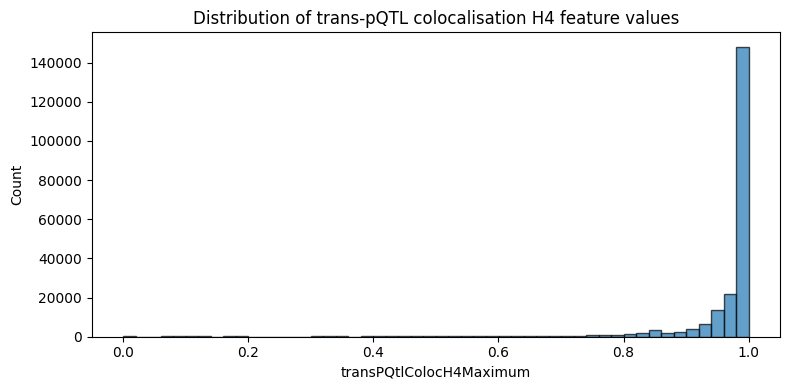

+-------+-------------------+
|summary|       featureValue|
+-------+-------------------+
|  count|             215639|
|   mean| 0.9588020854486283|
| stddev|0.11064533984209063|
|    min|       1.6718762E-4|
|    max|                1.0|
+-------+-------------------+



Unique studyLocusIds: 95,360


Unique geneIds:       582


26/04/29 00:53:54 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56) ~[spark-common-utils_2.12-3.5.1.jar:3.5.1]
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310) ~[spark-core_2.12-3.5.1.jar:3.5.1]
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75) ~[spark-core_2.12-3.5.1.jar:3.5.1]
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102) ~[spark-core_2.12-3.5.1.jar:3.5.1]
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110) ~[spark-core_2.12-3.5.1.jar:3.5.1]
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36) ~[spark-core_2.12-3.5.1.jar:3.5.1]
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124) ~[spark-core_2.12-3.5.1.jar:3.5.1]
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage

In [36]:
import matplotlib.pyplot as plt

scores_pd = feature.df.select("featureValue").toPandas()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(scores_pd["featureValue"].dropna(), bins=50, edgecolor="black", alpha=0.7)
ax.set_xlabel("transPQtlColocH4Maximum")
ax.set_ylabel("Count")
ax.set_title("Distribution of trans-pQTL colocalisation H4 feature values")
plt.tight_layout()
plt.show()

feature.df.describe("featureValue").show()

print(f"Unique studyLocusIds: {feature.df.select('studyLocusId').distinct().count():,}")
print(f"Unique geneIds:       {feature.df.select('geneId').distinct().count():,}")